In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pathlib

sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("deep", color_codes=True)

In [4]:
df_18 = pd.read_pickle("phase2_18_qubits_high_confidence_results.pkl")
df_22 = pd.read_pickle("phase2_22_qubits_high_confidence_results.pkl")

combined_df = pd.concat([df_18, df_22], ignore_index=True)
combined_df

,seed,bitstring,biological_energy,energy_diff,protein,residues,residue_count,rotamers,num_qubits,classification
0,0,"(0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, ...",152.377977,-0.545520,AF-5PTI,51_55,5,6,18,tie
1,1,"(1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, ...",151.877171,-1.046325,AF-5PTI,51_55,5,6,18,tie
2,2,"(0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, ...",152.282801,-0.640695,AF-5PTI,51_55,5,6,18,tie
3,3,"(1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, ...",152.956160,0.032663,AF-5PTI,51_55,5,6,18,tie
4,4,"(0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, ...",153.361799,0.438303,AF-5PTI,51_55,5,6,18,tie
...,...,...,...,...,...,...,...,...,...,...
355,25,"(1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, ...",153.002790,0.079294,AF-5PTI,53_60,8,7,22,tie
356,26,"(1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, ...",153.974535,1.051038,AF-5PTI,53_60,8,7,22,tie
357,27,"(1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, ...",153.804590,0.881094,AF-5PTI,53_60,8,7,22,tie
358,28,"(1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, ...",153.974535,1.051038,AF-5PTI,53_60,8,7,22,tie


In [7]:
df_18.describe()

,seed,biological_energy,energy_diff,residue_count,rotamers,num_qubits
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.0
mean,14.500000,153.206576,0.283080,6.714286,5.857143,18.0
std,8.676124,1.498635,1.498635,1.280806,0.834984,0.0
min,0.000000,150.935453,-1.988043,5.000000,5.000000,18.0
25%,7.000000,152.044251,-0.879245,5.000000,5.000000,18.0
50%,14.500000,152.987699,0.064203,7.000000,6.000000,18.0
75%,22.000000,154.472207,1.548711,8.000000,7.000000,18.0
max,29.000000,156.896257,3.972761,8.000000,7.000000,18.0


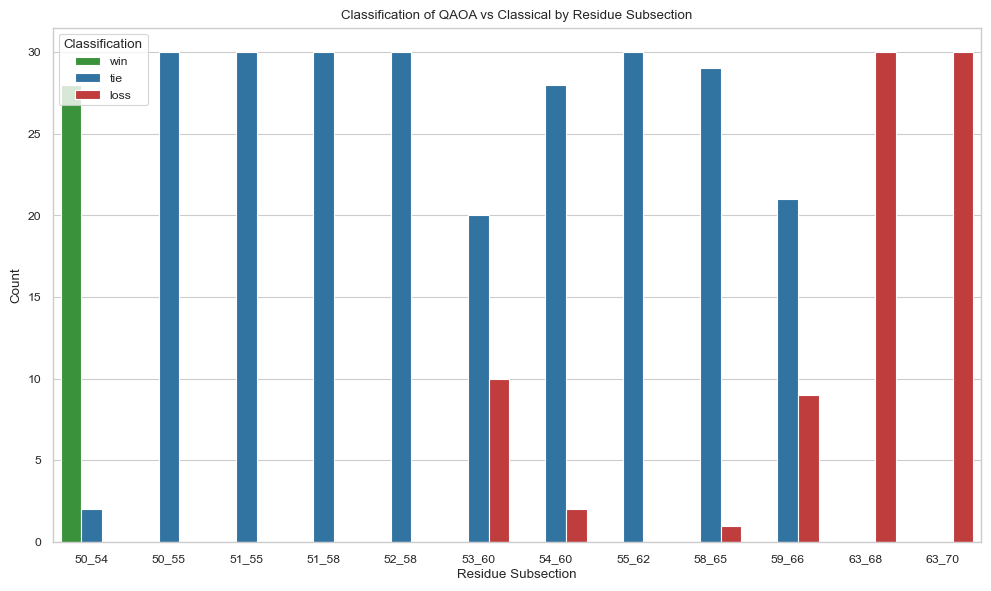

In [6]:
residue_order = (
    combined_df["residues"]
    .dropna()
    .unique()
)

residue_order = sorted(
    residue_order,
    key=lambda s: tuple(map(int, s.split("_")))  # e.g. "18_24" -> (18, 24)
)

hue_order = ["win", "tie", "loss"]

plt.figure(figsize=(10, 6))
sns.countplot(
    data=combined_df,
    x="residues",
    hue="classification",
    order=residue_order,
    hue_order=hue_order,
    palette={"win": "#2ca02c", "tie": "#1f77b4", "loss": "#d62728"},
)
plt.xlabel("Residue Subsection")
plt.ylabel("Count")
plt.title("Classification of QAOA vs Classical by Residue Subsection")
plt.legend(title="Classification")
plt.tight_layout()

# plt.savefig("../plots/classification_counts_5_10_qubits_by_subsection.svg", dpi=300, bbox_inches="tight")

plt.show()

In [7]:
df_18.classification.value_counts()

classification
tie     119
loss     63
win      28
Name: count, dtype: int64

In [8]:
df_22.classification.value_counts()

classification
tie     131
loss     19
Name: count, dtype: int64

In [11]:
combined_df[combined_df.classification == 'loss'].energy_diff.describe()

count    82.000000
mean      2.197157
std       0.697894
min       1.548711
25%       1.588425
50%       2.232700
75%       2.336786
max       4.392708
Name: energy_diff, dtype: float64